# Notebook 2: GLM Models
This notebook fits two GLMs:
- **Part 1 — Severity:** Gamma GLM with log-link, predicting claim amount given a claim occurred
- **Part 2 — Frequency:** Poisson GLM with log-link, predicting claim rate across all policies

The outputs of both models are combined in notebook 5 to estimate a pure premium.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

---
## Part 1: Severity — Gamma GLM

*Predicts how much a claim costs, given one occurred. Uses 26k claims dataset.*

In [ ]:
df = pd.read_csv('../data/claims_cleaned.csv')

print(df.shape)
df.head()

(26439, 13)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
0,139.0,1,0.75,F,7,1,61,50,B12,'Regular',27000,R11,303.00
1,190.0,1,0.14,B,12,5,50,60,B12,'Diesel',56,R25,1981.84
2,414.0,1,0.14,E,4,0,36,85,B12,'Regular',4792,R11,1456.55
3,424.0,2,0.62,F,10,0,51,100,B12,'Regular',27000,R11,989.64
4,424.0,2,0.62,F,10,0,51,100,B12,'Regular',27000,R11,9844.36


In [16]:
# Features to use — drop IDpol (ID), Exposure and ClaimNb (not relevant for severity)
features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target = 'ClaimAmount'

# Changing the categorical columns: Area, VehBrand, VehGas, Region into numeric columns
# Hint: use pd.get_dummies with drop_first=True
# df[features + [target]] -> subsetting to only the features and the target variable.
df_model = pd.get_dummies(df[features + [target]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)
df_model = df_model.astype(float)

print(f'Features after encoding: {df_model.shape[1] - 1}')

Features after encoding: 42


In [ ]:
X = df_model.drop(columns=[target])
y = df_model[target]

# Split into train/test sets (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (21151, 42), Test: (5288, 42)


## 2. Fit Gamma GLM

Using `statsmodels` which gives full statistical output (p-values, confidence intervals).

Gamma — the distribution we assume for ClaimAmount. We use it because:                                                
  - Claims are always positive (can't have a negative claim)
  - The distribution is right-skewed, which Gamma handles naturally                                                     
  - Errors are proportional — a €500 error on a €1,000 claim is worse than a €500 error on a €10,000 claim. Gamma
  captures this.                                                                                                        
                                                                                                                        
  Log-link — the function connecting the features to the prediction. We use it because:
  - It ensures predictions are always positive (you can't predict a negative claim amount)                              
  - It means the model is multiplicative — each feature multiplies the expected claim by some factor, which makes       
  actuarial sense (e.g. a high-power vehicle multiplies your expected claim by 1.1x)                                    
                                                                                                                        
  The alternative would be plain linear regression, which assumes normally distributed errors and can predict negative
  values — neither of which makes sense for insurance claims.

In [20]:
# adding an intercept column to ensure the model doesn't simply pass through the origin.
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# TODO: fit a Gamma GLM with log-link using sm.GLM
# Hint: family=sm.families.Gamma(link=sm.families.links.Log())
gamma_log_model = sm.GLM(y_train, X_train_sm, family=sm.families.Gamma(link=sm.families.links.Log()))

# Result is the gamma log model.
result = gamma_log_model.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                21151
Model:                            GLM   Df Residuals:                    21108
Model Family:                   Gamma   Df Model:                           42
Link Function:                    Log   Scale:                          1.9642
Method:                          IRLS   Log-Likelihood:            -1.7997e+05
Date:                Thu, 26 Mar 2026   Deviance:                       21794.
Time:                        00:10:47   Pearson chi2:                 4.15e+04
No. Iterations:                    13   Pseudo R-squ. (CS):           0.006289
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.1136      0.086  

## 3. Evaluate on Test Set

In [19]:
# TODO: generate predictions on the test set
y_pred = result.predict(X_test_sm)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Gamma deviance — the actuarially correct metric for severity models
# Penalises proportional errors rather than absolute ones
def gamma_deviance(y_true, y_pred):
    return 2 * np.mean((y_true - y_pred) / y_pred - np.log(y_true / y_pred))

gd = gamma_deviance(y_test.values, y_pred.values)

print('--- GLM Test Set Performance ---')
print(f'MAE:             {mae:,.2f}')
print(f'RMSE:            {rmse:,.2f}')
print(f'Gamma Deviance:  {gd:.4f}')

# Save for final comparison
glm_metrics = {'model': 'GLM', 'MAE': mae, 'RMSE': rmse, 'GammaDeviance': gd}

--- GLM Test Set Performance ---
MAE:             1,079.28
RMSE:            2,203.43
Gamma Deviance:  1.0314


## 4. Visualise Predictions vs Actuals

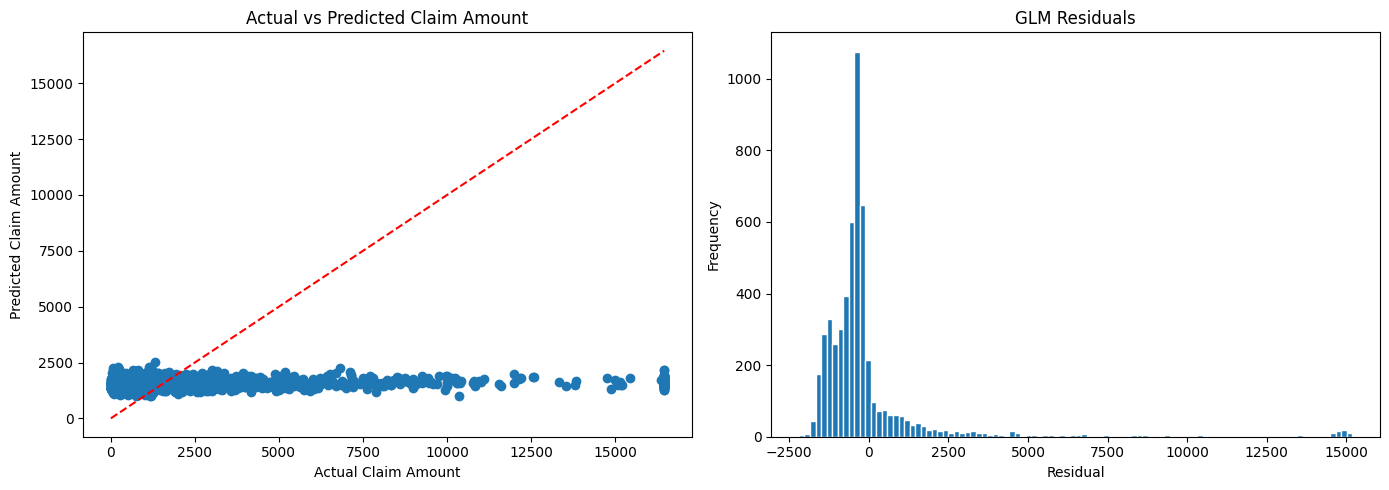

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of y_test (x-axis) vs y_pred (y-axis)
# Add a red dashed diagonal line to show perfect predictions
axes[0].scatter(y_test, y_pred)

min_val = y_test.min()                                                                                                
max_val = y_test.max()                                                                                                
axes[0].plot([min_val, max_val], [min_val, max_val], color='r', linestyle='--')

axes[0].set_xlabel('Actual Claim Amount')
axes[0].set_ylabel('Predicted Claim Amount')
axes[0].set_title('Actual vs Predicted Claim Amount')

# Histogram of residuals (y_test - y_pred)
axes[1].hist(y_test - y_pred, bins=100, edgecolor='white')
axes[1].set_title('GLM Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/03_glm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

- MAE: €1,079. On average predictions are €1,079 off, against a mean claim of €1,569.                                 
  - RMSE: €2,203. Heavily influenced by large claims the model cannot predict.
  - Gamma Deviance: 1.03                                                                                                
  - Predictions cluster tightly between €1,000 and €2,000 regardless of actual claim size. The model captures the
  average well but cannot distinguish high-severity claims from low ones.                                               
  - Pseudo R² of 0.006 confirms very little variance is explained individually.
                                                                                                                        
  Significant coefficients:                                 
  - BonusMalus (positive): higher claims history leads to higher severity.
  - VehAge (negative): older vehicles have lower claim amounts, likely due to lower market value.
  - VehPower (positive): more powerful vehicles are associated with higher claims.               
  - Several regions are significant (R93, R94, R41), suggesting geographic differences in repair costs.                 
   
  Key takeaway: The GLM performs as expected for a severity baseline. The flat prediction pattern is a known limitation 
  of linear models on heavy-tailed data. XGBoost should improve on this by capturing non-linear interactions between
  features.

## 5. Coefficient Interpretation

Key advantage of GLM over XGBoost/neural net — coefficients are directly interpretable.

In [ ]:
# On a log-link GLM, exp(coef) = multiplicative effect on claim amount
# e.g. exp(coef) = 1.10 means that feature increases expected claim by 10%

# TODO: create a dataframe of coefficients, their exponentiated values, and p-values
# Hint: result.params, result.pvalues
coef_df = None

print(coef_df.sort_values('exp_coef', ascending=False).head(10).to_string())

---
### Appendix: Why Gamma over OLS?

Fits a plain OLS regression on the same data and compares predictions and metrics. This demonstrates concretely why OLS is inappropriate for claim severity.

In [ ]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression().fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

# OLS can predict negative claim amounts
n_negative = (y_pred_ols < 0).sum()
print(f'OLS negative predictions: {n_negative} ({n_negative/len(y_pred_ols):.1%})')

# Compare metrics
mae_ols  = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = mean_squared_error(y_test, y_pred_ols) ** 0.5

print(f'\n{"":20} {"GLM":>10} {"OLS":>10}')
print(f'{"MAE":20} {mae:>10,.2f} {mae_ols:>10,.2f}')
print(f'{"RMSE":20} {rmse:>10,.2f} {rmse_ols:>10,.2f}')
print(f'\nConclusion: OLS produces negative predictions and higher errors.')
print('Gamma GLM is the correct choice for positive, right-skewed targets.')

---
## Part 2: Frequency — Poisson GLM

*Predicts the probability of a claim occurring. Uses the full 679k policies dataset.*

**Why Poisson?** Claim counts are non-negative integers — the Poisson distribution is the standard actuarial choice for modelling count data. The log-link ensures predictions are always positive.

**Exposure offset:** Policies have different durations (Exposure column, in years). A policy active for 0.5 years has half the opportunity to claim. We account for this by including log(Exposure) as an offset in the model.

### 2.1 Load & Prepare Data

In [33]:
# Load policies_cleaned.csv from the data folder
df_freq = pd.read_csv('../data/freMTPL2freq.csv')

print(df_freq.shape)
df_freq.head()

(678013, 12)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


In [39]:
features_freq = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target_freq = 'ClaimNb'

# one-hot encode categorical columns and convert to float (same as severity section)
df_freq_model = pd.get_dummies(df_freq[features_freq + [target_freq]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)
df_freq_model = df_freq_model.astype(float)

# Separate out exposure before dropping — needed as offset
exposure = df_freq['Exposure']

X_freq = df_freq_model.drop(columns=[target_freq])
y_freq = df_freq_model[target_freq]

# train/test split (80/20, random_state=42)
# Make sure to split exposure with the same indices
X_freq_train, X_freq_test, y_freq_train, y_freq_test, exp_train, exp_test = train_test_split(X_freq, y_freq, exposure, test_size=0.2, random_state=42)

print(f'Train: {X_freq_train.shape}, Test: {X_freq_test.shape}')

Train: (542410, 42), Test: (135603, 42)


### 2.2 Fit Poisson GLM

In [41]:
X_freq_train_sm = sm.add_constant(X_freq_train)
X_freq_test_sm  = sm.add_constant(X_freq_test)

# TODO: fit a Poisson GLM with log-link using sm.GLM
# Include log(exposure) as an offset: offset=np.log(exp_train)
# Hint: family=sm.families.Poisson(link=sm.families.links.Log())
result_freq = sm.GLM(y_freq_train, X_freq_train_sm, family=sm.families.Poisson(link=sm.families.links.Log())).fit()

print(result_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542367
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1301e+05
Date:                Thu, 26 Mar 2026   Deviance:                   1.7063e+05
Time:                        17:42:19   Pearson chi2:                 5.92e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.006456
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -4.6327      0.053  

Significant predictors (all p < 0.001):                                                                               
  - BonusMalus (positive, strongest): higher claims history score leads to more claims. Coefficient of 0.0178 means each
   point increase multiplies expected claim frequency by $e^{0.017} = 1.018$.                                              
  - DrivAge (positive): older drivers claim slightly more often in this dataset, which seems counterintuitive. Likely confounded by exposure or policy mix.                                                                                 
  - VehAge (negative): newer vehicles claim more frequently, possibly because they are driven more.     
  - Area D and E (positive): higher claim rates in those areas, consistent with the EDA findings.
                                                                                                                        
  Compared to the severity model:                                                                                       
  - Much stronger signal overall. BonusMalus and DrivAge are highly significant here but were weak in the severity      
  model.                                                                                                                
  - Pseudo R² of 0.006 is similar, but with 542k observations the z-scores are much larger, meaning we can detect
  smaller real effects.

### 2.3 Evaluate on Test Set

In [43]:
# TODO: generate predictions on the test set
# Remember to pass offset=np.log(exp_test) when predicting
y_freq_pred = result_freq.predict(X_freq_test_sm, offset=np.log(exp_test))

mae_freq  = mean_absolute_error(y_freq_test, y_freq_pred)
rmse_freq = mean_squared_error(y_freq_test, y_freq_pred) ** 0.5

# Poisson deviance — correct metric for count models
def poisson_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, None)
    return 2 * np.sum(y_true * np.log(np.where(y_true == 0, 1, y_true / y_pred)) - (y_true - y_pred))

pd_score = poisson_deviance(y_freq_test.values, y_freq_pred)

print('--- Poisson GLM Test Set Performance ---')
print(f'MAE:               {mae_freq:.4f}')
print(f'RMSE:              {rmse_freq:.4f}')
print(f'Poisson Deviance:  {pd_score:.2f}')

glm_freq_metrics = {'model': 'GLM', 'MAE': mae_freq, 'RMSE': rmse_freq, 'PoissonDeviance': pd_score}

--- Poisson GLM Test Set Performance ---
MAE:               0.0774
RMSE:              0.2383
Poisson Deviance:  46581.25


- MAE of 0.077 means predictions are on average 0.077 claims off. Given the overall claim rate is 3.9%, this is reasonable.                                                                                                           
  - RMSE of 0.238 is higher due to the large number of zero-claim policies pulling predictions away from actuals.       
  - Poisson Deviance of 46,581 is a large absolute number but that is expected with 135k test records. It is more useful
   for comparison against XGBoost and the neural net later.

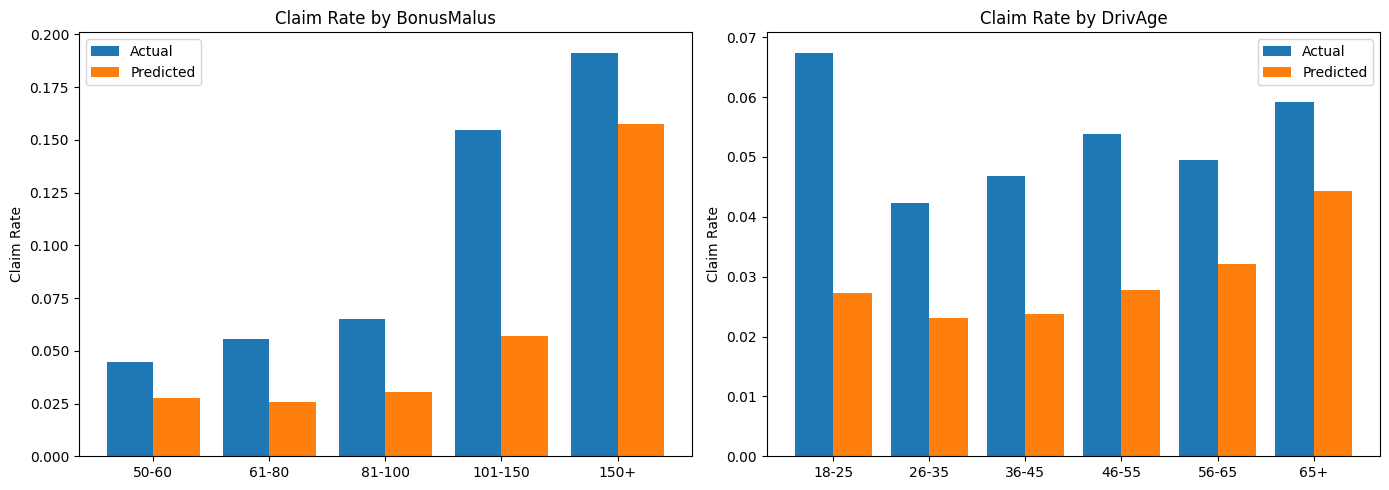

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                       

# Get predictions on full training + test set for this analysis                                                       
X_all_sm = sm.add_constant(pd.concat([X_freq_train, X_freq_test]))
exp_all = pd.concat([exp_train, exp_test])
df_freq['predicted_rate'] = result_freq.predict(X_all_sm, offset=np.log(exp_all))
df_freq['HasClaim'] = (df_freq['ClaimNb'] != 0).astype(int)
df_freq['actual_rate'] = df_freq['HasClaim']

# BonusMalus
bm_bins = pd.cut(df_freq['BonusMalus'], bins=[49,60,80,100,150,230],
labels=['50-60','61-80','81-100','101-150','150+'])
actual_bm = df_freq.groupby(bm_bins)['actual_rate'].mean()
pred_bm = df_freq.groupby(bm_bins)['predicted_rate'].mean()

x = range(len(actual_bm))
axes[0].bar(x, actual_bm, width=0.4, label='Actual', align='center')                                                  
axes[0].bar([i + 0.4 for i in x], pred_bm, width=0.4, label='Predicted', align='center')                              
axes[0].set_xticks([i + 0.2 for i in x])                                                                              
axes[0].set_xticklabels(actual_bm.index)                                                                              
axes[0].set_title('Claim Rate by BonusMalus')                                                                         
axes[0].set_ylabel('Claim Rate')                          
axes[0].legend()                                                                                                      
                                                                                                                    
# DrivAge
age_bins = pd.cut(df_freq['DrivAge'], bins=[17,25,35,45,55,65,100],                                                   
labels=['18-25','26-35','36-45','46-55','56-65','65+'])                                                               
actual_age = df_freq.groupby(age_bins)['actual_rate'].mean()
pred_age = df_freq.groupby(age_bins)['predicted_rate'].mean()                                                         
                                                        
x = range(len(actual_age))                                                                                            
axes[1].bar(x, actual_age, width=0.4, label='Actual', align='center')
axes[1].bar([i + 0.4 for i in x], pred_age, width=0.4, label='Predicted', align='center')                             
axes[1].set_xticks([i + 0.2 for i in x])
axes[1].set_xticklabels(actual_age.index)                                                                             
axes[1].set_title('Claim Rate by DrivAge')                                                                            
axes[1].set_ylabel('Claim Rate')
axes[1].legend()                                                                                                      
                                                        
plt.tight_layout()
plt.savefig('../results/04_freq_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

**BonusMalus (left)**

The model correctly captures the upward trend. Predicted rates rise monotonically as BonusMalus increases, which reflects the coefficient being positive and significant in the GLM summary.

However the model consistently underpredicts across all bins, and the magnitude of underprediction varies considerably. For the three lowest risk bins (50-60, 61-80, 81-100) predictions sit around 0.025-0.030 while actual rates range from 0.046 to 0.065. This is a systematic underestimate of roughly 50-60% in these groups. The model performs best at the highest risk band (150+) where predicted 0.158 is close to actual 0.191, a gap of around 17%.

This compression toward the mean is a known limitation of GLMs with few features. The model cannot fully separate the cleanest drivers from average-risk drivers because BonusMalus alone, as a linear term, does not carry enough discriminating power at the lower end of the range. In practice actuaries often apply credibility adjustments or add interaction terms to address this.

**DrivAge (right)**

Young drivers (18-25) are clearly the highest risk group at 0.068. Rates drop sharply into the mid-twenties, remain relatively stable through middle age at around 0.043-0.055, then rise modestly for the 65+ group to 0.059.

The GLM substantially underpredicts all age groups, with predictions ranging only from 0.023 to 0.046. More importantly it fails to capture the non-linear shape of the relationship. The model predicts a gentle upward slope across age groups rather than the sharp peak at 18-25 and the moderate elevation at 65+. Middle-aged drivers (26-45) are the least risky in reality but the model assigns them almost the same predicted rate as older drivers.

This is a direct consequence of the GLM treating DrivAge as a linear predictor. The actual relationship requires at minimum a quadratic term or binned age categories to fit properly. This is precisely the limitation XGBoost will address since tree-based models find non-linear splits automatically. We would expect XGBoost to much better separate the 18-25 group from the rest and to correctly identify the modest uptick at 65+.

**Overall**

Both charts point to the same underlying issue. The Poisson GLM captures the direction of relationships correctly but compresses predictions toward the mean and misses non-linearities. This is expected for a baseline model. The Poisson deviance of 46,581 and the calibration gaps here set the benchmark that XGBoost and the neural network will be judged against.